# Module 2: Epidemic Modeling Template

## Team Members: Will Marschall and Reagan Oswald

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

#### Data Release 1 (Initial Estimates and Approximations)

We loaded the Data Release #1 CSV containing day number and active reported daily cases, and plotted **day vs. active infections**.

To estimate early spread speed, we used the Day 2 approach that early epidemic growth can be approximated as continuous exponential growth, $(I(t) = I_0 e^{rt})$, where $(r)$ is estimated by fitting an exponential curve to early infection data.


We then estimated $(R_0)$ using the Day 2 approximation $R_0 \approx e^{rD}$, where $(D)$ is the infectious period. For $(D)$, we used the “New information about our mystery virus” statement that the symptomatic period is 5–9 days and individuals are infectious for 2 days before symptoms appear, giving $(D \approx [7, 11])$ days.

Finally, we used the course-provided `viruses.html` visualization to identify diseases with similar $R_0$ and compare approximate transmissibility and case fatality rate (CFR).

#### Data Release 2 (SEIR modeling + parameter fitting)

For Data Release #2, we modeled the outbreak using an **SEIR compartment model** and solved the system numerically with **Euler’s method**. Euler’s method uses the update rule $y_{i+1}=y_i+f(t_i,y_i)h$. We used the SEIR differential equations shown in lecture:
$\frac{dS}{dt}=-\beta \frac{SI}{N}$,
$\frac{dE}{dt}=\beta \frac{SI}{N}-\sigma E$,
$\frac{dI}{dt}=\sigma E-\gamma I$,
$\frac{dR}{dt}=\gamma I$

We then fit parameters $\beta$ (transmission), $\sigma$ (incubation/latency rate), and $\gamma$ (recovery rate) by performing a 3-parameter grid search that minimizes the objective function
$\mathrm{SSE}=\sum (I_{\mathrm{obs}}-I_{\mathrm{model}})^2$
We used the parameter ranges and resolution specified in `seir_grid_search.html`: $\beta \in [0.3,0.7]$, $\sigma \in [0.1,0.3]$, $\gamma \in [0.05,0.25]$ with 15 points per parameter.

Finally, we computed an implied basic reproduction number using the relationship $R_0=\beta/\gamma$ and predicted the peak by running the best-fit model forward in time and finding the maximum of $I(t)$.

**Modeling assumption:** We set $N=10{,}000$ to match the example population size. If a different population size is wanted for the mystery outbreak, $N$ can be updated accordingly.

#### Data Release 3 


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section comes from the python code after Data Release #1.

### **Day 1 - Part 2B**

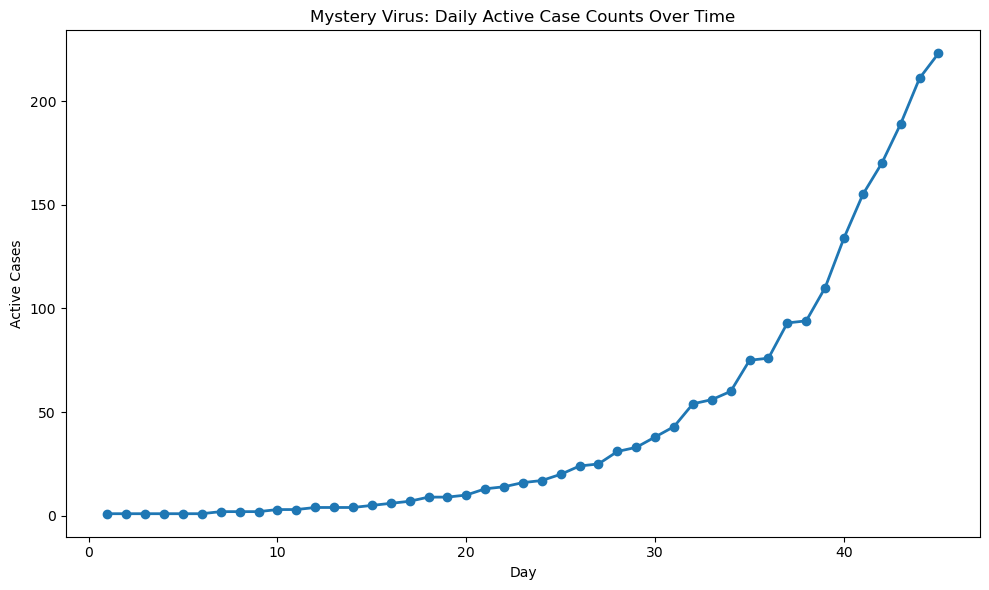

In [10]:
from IPython.display import display, Markdown

def step(title: str):
    display(Markdown(f"### **{title}**"))

step("Day 1 - Part 2B")
import main
main.exploratory_analysis_day1_2b()

**1 What do you notice about the initial infections?**

Initially in the earlier days the infection has spead to few pople. But the number of active cases increases exponentially because when more people are infected, they can spread teh infecton much more quickly

**2 How could we measure how quickly its spreading?**

By finding the rate of change of the graph we can measure how quickly the infection spreads as a rate across days. 

**3 What information about the virus would be helpful in determining the shape of the outbreak curve?**

It would be helpful to know how the virus spreads. Viruses that spread more easily will likely have a greater rate of  infection and result in a greater outbreak curve. For example, an airporn virus may infect a population faster than one that spreads fluids

### **Day 2 - Part 2B**

Fit window: day >= 10
Estimated exponential growth rate r: 0.1197 per day
Estimated R0 range using D in [7.0, 11.0] days:
  R0_min (D=7.0) = 2.312
  R0_mid (D=9.0) = 2.937
  R0_max (D=11.0) = 3.732


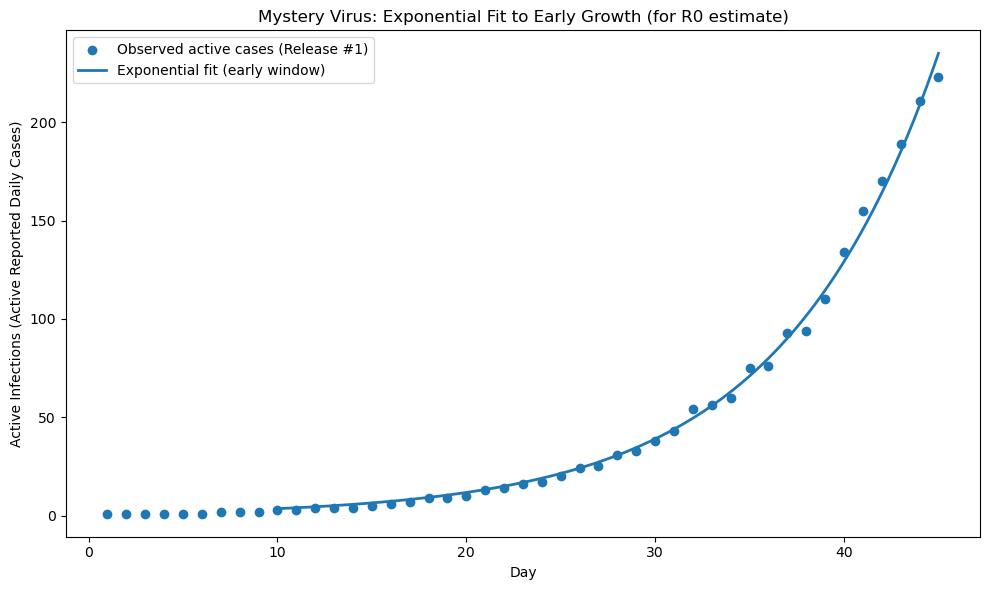

In [9]:
step("Day 2 - Part 2B")
main.exploratory_analysis_day2_2b()

**What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.**

**RESPONSE:** COVID-19 (Original) was found to be near my R0 (2.937). It reported to have a R0 of 3 and CFR = 1%, and it is marked under the "Vaccine Available" category. COVID-19 is has an ~5-day incubation period and it can be infectious ~2 days before symptoms.

**RESPONSE:** Zika was found to be near my R0 (2.937). It reported to have a R0 of 3 and CFR = 0.02%, and it is marked under the "No Vaccine" category. Zika virus is a mosquito-borne pathogen that gained global attention during a 2015 outbreak.

**How accurate do you think your R0 estimate is?**

**RESPONSE:** my R0 is reasonable but approximate, because we explicitly treat this as an early-epidemic approximation based on fitting exponential growth and then converting. The biggest uncertainty is D (infectious period) as we only have limited timing information (symptomatic period 5-9 days). Also the fitted growth rate r can change depending on which days we treat as the "early exponential window" (we chose day >= 10, and viruses.html notes that R0 estimates vary with behavior and population density).


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.

### **Day 3 - Part 2C**

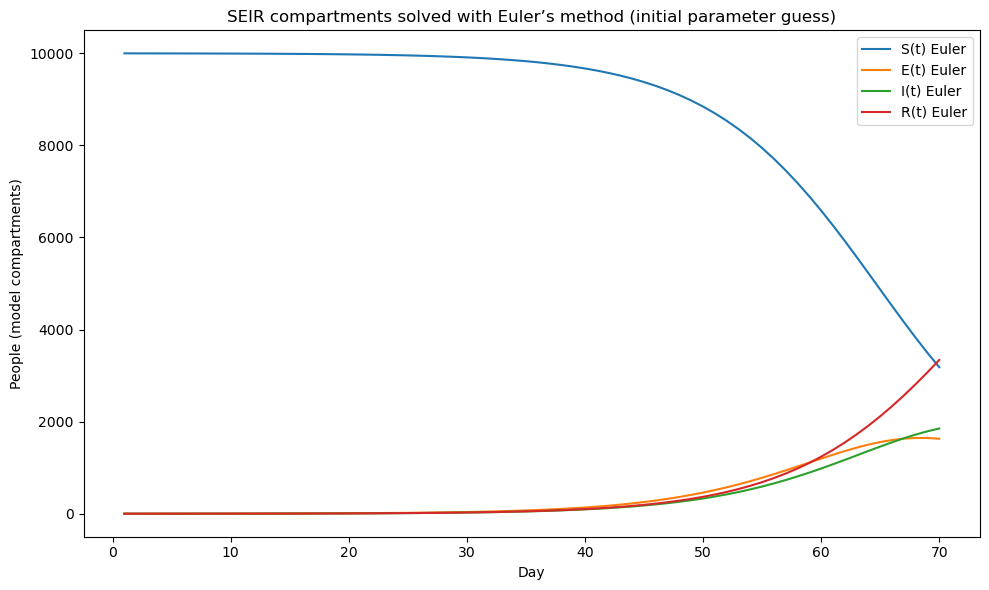

In [5]:
step("Day 3 - Part 2C")
main.exploratory_analysis_day3_2c()

### 2c. Use Euler's method to solve the SEIR model.

We solved the SEIR system using Euler’s method, applying the update rule $y_{i+1}=y_i+f(t_i,y_i)h$.

Using an initial parameter guess within the grid-search ranges ($\beta=0.5,\sigma=0.2,\gamma=0.15$; chosen as mid-range values from `seir_grid_search.html`), the Euler solution produced the expected qualitative compartment behavior: $S(t)$ decreases while $E(t),I(t),R(t)$ increase over the observed 70 days. This confirms that our Euler implementation is correctly propagating the SEIR dynamics described in the lecture equations.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

In [6]:
step("Day 3 - Part 2D")
main.exploratory_analysis_day3_2d()

### **Day 3 - Part 2D**

Best-fit parameters from 3-parameter grid search (min SSE):
  beta  = 0.586
  sigma = 0.114
  gamma = 0.107
  SSE   = 98824.33
  Implied R0 (Lecture 2: R0 = beta/gamma) = 5.467


We fit $\beta,\sigma,\gamma$ using a 3-parameter grid search that minimizes
$\mathrm{SSE}=\sum (I_{\mathrm{obs}}-I_{\mathrm{model}})^2$. We used the ranges/resolution from `seir_grid_search.html`:
$\beta \in [0.3,0.7]$, $\sigma \in [0.1,0.3]$, $\gamma \in [0.05,0.25]$ with 15 points per parameter.

Best-fit results (minimum SSE):

- $\beta = 0.586$

- $\sigma = 0.114$

- $\gamma = 0.107$

- $\mathrm{SSE} = 98{,}824.33$

Using the relationship $R_0=\beta/\gamma$, the implied
$R_0 \approx 0.586/0.107 \approx 5.467$.

Interpreting $\sigma$ and $\gamma$ using definitions ($\sigma=1/\text{latent period}$, $\gamma=1/\text{infectious period}$:

- Latent period $\approx 1/\sigma \approx 1/0.114 \approx 8.8$ days

- Infectious period $\approx 1/\gamma \approx 1/0.107 \approx 9.3$ days

### 2e. Plot the model-predicted infections over time compared to the data.

### **Day 3 - Part 2E**

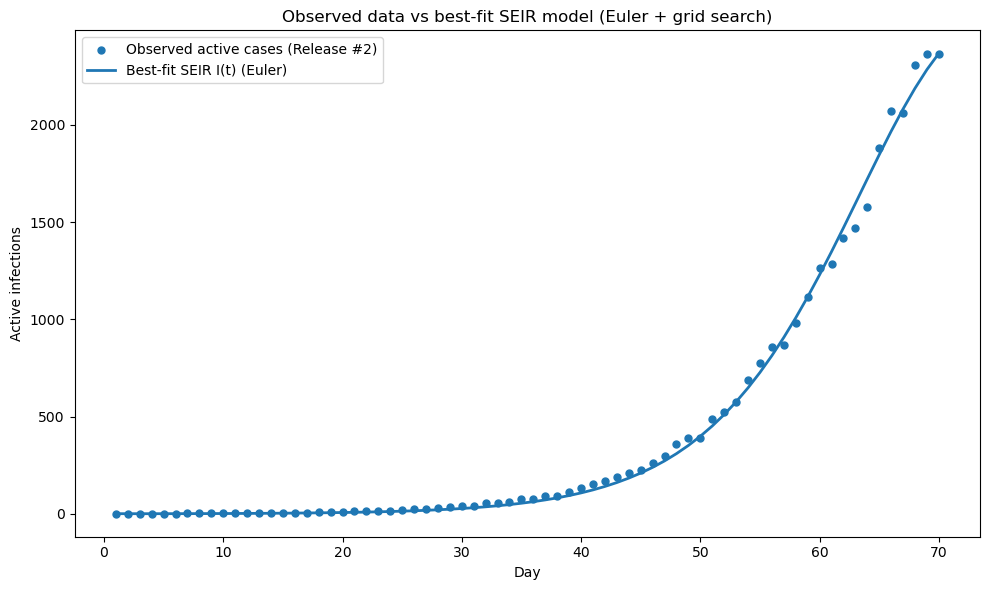

In [7]:
step("Day 3 - Part 2E")
main.exploratory_analysis_day3_2e()

Using the best-fit parameters from 2d, we solved the SEIR model again with Euler’s method and plotted the model-predicted $I(t)$ against the observed active infection counts from Data Release #2.

Visually, the best-fit SEIR curve closely tracks the observed data through the rapid growth phase and remains near the final observed values (e.g., the dataset reaches 2,363 active cases at day 70). This indicates the chosen $\beta,\sigma,\gamma$ minimize SSE over the full 70-day dataset under the grid-search procedure.

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread.

### **Day 3 - Part 2F**


Peak prediction from best-fit model (running forward):
  Peak day (model)        = 75
  Peak active infections  = 2556.4


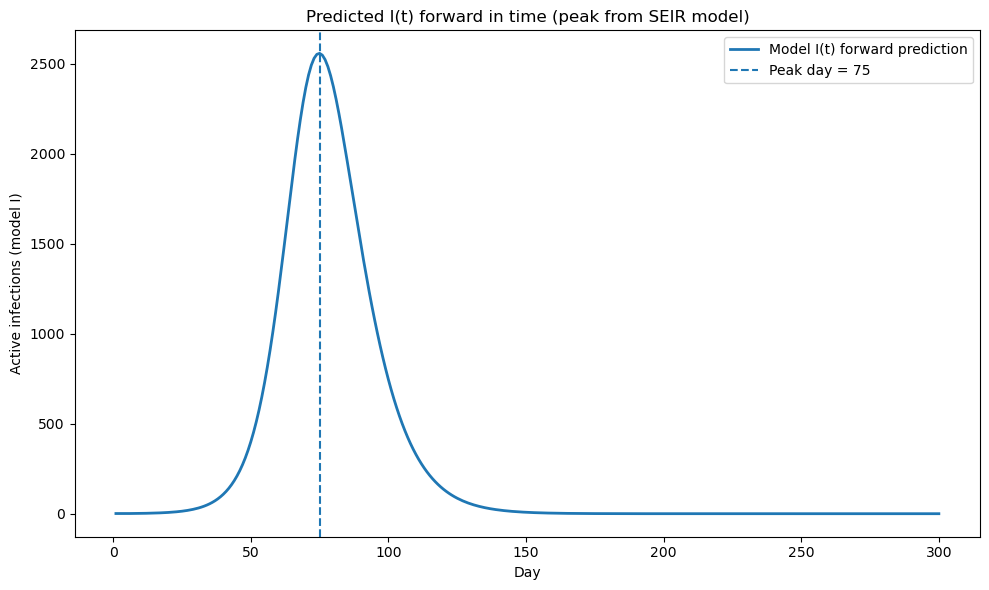

In [8]:
step("Day 3 - Part 2F")
main.exploratory_analysis_day3_2f()

Lecture 3 describes predicting the peak by running the best-fit model forward in time and finding when $I(t)$ reaches its maximum. Using our best-fit $\beta,\sigma,\gamma$, we ran the Euler SEIR simulation forward to day 300 and located the maximum of $I(t)$.

Peak prediction (model):

- Predicted peak day = 75

- Predicted peak active infections = 2,556.4

Because the observed dataset ends at day 70 with 2,363 active infections, the model predicts the peak occurs about 5 days after the last observation and rises by about 193.4 active cases beyond the day-70 observed value.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2h. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## **Notes:** 

* **Completed:**

    * Data and Disease Background

    * Data Analysis 

    * Verification/Validation 
    
    * Conclusions/Ethics

    * Limitations/Future Work

* **To Do:**

    * Nothing at this time.

* **Questions/Concerns:**

    * Nothing at this time.

* **References:**

    * 

    * 

    * 

    * 

* **AI Statement:**

    * 





## **TA Questions:** 
*We have no questions at this time.*